<a href="https://colab.research.google.com/github/sharanperris/CSE437-Data-Science-Project/blob/main/CSE437_PROJECT_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Serial Killer Typology Discovery via K-Means Clustering**

In [ ]:
!pip install kaggle
import os

In [ ]:
import kagglehub
path = kagglehub.dataset_download("abdullahsamiir/serial-killers-wiki")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'serial-killers-wiki' dataset.
Path to dataset files: /kaggle/input/serial-killers-wiki


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv(os.path.join(path, "serial_killers.csv"))
df.info()
print(df.shape)
print(df.dtypes)
display(df.isnull().sum())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1531 entries, 0 to 1530
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              1531 non-null   object
 1   Country           1531 non-null   object
 2   Years active      1531 non-null   object
 3   Proven victims    1531 non-null   object
 4   Possible victims  1531 non-null   object
 5   Notes             1531 non-null   object
dtypes: object(6)
memory usage: 71.9+ KB
(1531, 6)
Name                object
Country             object
Years active        object
Proven victims      object
Possible victims    object
Notes               object
dtype: object


,0
Name,0
Country,0
Years active,0
Proven victims,0
Possible victims,0
Notes,0


,Name,Country,Years active,Proven victims,Possible victims,Notes
0,Luis Garavito,Colombia Ecuador[3] Venezuela[3],1992–1999[3],193,193–300+,"Child-murderer, torture-killer, and rapist kno..."
1,Pedro López,Colombia Peru Ecuador,1969–1980,110,300+,"Child-murderer and rapist, known as ""The Monst..."
2,Javed Iqbal,Pakistan,1998–1999,100,100,"Child-murderer and rapist, known as ""Kukri"", I..."
3,Mikhail Popkov,Russia,1992–2010,78,83+,"Serial rapist-killer nicknamed ""The Werewolf"",..."
4,Daniel Camargo Barbosa,Colombia Ecuador Brazil (alleged)[13],1974–1986,72,180[13],"Child and woman murderer, believed to have pos..."


### Preprocessing

 ## Years active

In [ ]:
def parse_years_active(years_str):
    if pd.isna(years_str):
        return np.nan, np.nan

    years_str = str(years_str).strip().replace('\xa0', ' ').replace('\u2013', '-')


    if 's' in years_str and years_str.replace('s', '').isdigit():
        start_year = int(years_str.replace('s', ''))
        end_year = start_year + 99
        return start_year, end_year

    years_str = re.sub(r'\[\d+\]', '', years_str).strip()

    years = [int(s) for s in re.findall(r'\d+', years_str)]

    if not years:
        return np.nan, np.nan

    if len(years) == 1:
        return years[0], years[0]
    elif len(years) == 2:
        return min(years), max(years)
    else:
        return min(years), max(years)



df['start_year'], df['end_year'] = zip(*df['Years active'].apply(parse_years_active))

df['active_duration'] = df['end_year'] - df['start_year'] + 1


display(df[['Years active', 'start_year', 'end_year', 'active_duration']].head())
display(df[['Years active', 'start_year', 'end_year', 'active_duration']].sample(5))


,Years active,start_year,end_year,active_duration
0,1992–1999[3],1992,1999,8
1,1969–1980,1969,1980,12
2,1998–1999,1998,1999,2
3,1992–2010,1992,2010,19
4,1974–1986,1974,1986,13


,Years active,start_year,end_year,active_duration
1457,1933,1933,1933,1
585,c. 1894,1894,1894,1
1402,1913,1913,1913,1
1230,1969–1980,1969,1980,12
78,1967–1980,1967,1980,14


## Proven victims, Possible victims

In [ ]:
def clean_victim_counts(victim_str):
    if pd.isna(victim_str):
        return np.nan

    victim_str = str(victim_str).strip().lower()

    if victim_str in ['unconfirmed', 'unknown', 'na', 'n/a']:
        return np.nan
    elif 'numerous' in victim_str:
        return 1000
    elif 'hundreds' in victim_str:
        return 500

    numbers = re.findall(r'\d+', victim_str)

    if numbers:
        try:
            return int(numbers[0])
        except ValueError:
            return np.nan
    else:
        return np.nan

df['Proven victims_cleaned'] = df['Proven victims'].apply(clean_victim_counts).astype(float)
df['Possible victims_cleaned'] = df['Possible victims'].apply(clean_victim_counts).astype(float)

display(df[['Proven victims', 'Proven victims_cleaned', 'Possible victims', 'Possible victims_cleaned']].head())
display(df[['Proven victims', 'Proven victims_cleaned', 'Possible victims', 'Possible victims_cleaned']].sample(5))

print(f"Non-numeric values in 'Proven victims_cleaned': {df['Proven victims_cleaned'].isnull().sum()}")
print(f"Non-numeric values in 'Possible victims_cleaned': {df['Possible victims_cleaned'].isnull().sum()}")


,Proven victims,Proven victims_cleaned,Possible victims,Possible victims_cleaned
0,193,193.0,193–300+,193.0
1,110,110.0,300+,300.0
2,100,100.0,100,100.0
3,78,78.0,83+,83.0
4,72,72.0,180[13],180.0


,Proven victims,Proven victims_cleaned,Possible victims,Possible victims_cleaned
558,Unconfirmed,NaN,8,8.0
1049,20,20.0,20+,20.0
961,10,10.0,10+,10.0
518,Unconfirmed,NaN,1–8,1.0
376,5,5.0,48+,48.0


Non-numeric values in 'Proven victims_cleaned': 123
Non-numeric values in 'Possible victims_cleaned': 145


## Name

In [ ]:
unknown_names = df[df['Name'].str.lower().str.contains('unknown', na=False)]
print(f"Number of entries with 'unknown' in Name: {len(unknown_names)}")

df['Name'] = df['Name'].replace({'unknown': np.nan, 'Unknown': np.nan})
print(f"Number of NaN in 'Name' after replacement: {df['Name'].isnull().sum()}")


Number of entries with 'unknown' in Name: 14
Number of NaN in 'Name' after replacement: 14


### Final Check

In [ ]:
for col in ['Name', 'Country', 'Years active', 'Proven victims', 'Possible victims', 'Notes']:
    if df[col].dtype == 'object':
        df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)


df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1531 entries, 0 to 1530
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      1517 non-null   object 
 1   Country                   1531 non-null   object 
 2   Years active              1531 non-null   object 
 3   Proven victims            1531 non-null   object 
 4   Possible victims          1531 non-null   object 
 5   Notes                     1531 non-null   object 
 6   start_year                1531 non-null   int64  
 7   end_year                  1531 non-null   int64  
 8   active_duration           1531 non-null   int64  
 9   Proven victims_cleaned    1408 non-null   float64
 10  Possible victims_cleaned  1386 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 131.7+ KB


,Name,Country,Years active,Proven victims,Possible victims,Notes,start_year,end_year,active_duration,Proven victims_cleaned,Possible victims_cleaned
0,Luis Garavito,Colombia Ecuador[3] Venezuela[3],1992–1999[3],193,193–300+,"Child-murderer, torture-killer, and rapist kno...",1992,1999,8,193.0,193.0
1,Pedro López,Colombia Peru Ecuador,1969–1980,110,300+,"Child-murderer and rapist, known as ""The Monst...",1969,1980,12,110.0,300.0
2,Javed Iqbal,Pakistan,1998–1999,100,100,"Child-murderer and rapist, known as ""Kukri"", I...",1998,1999,2,100.0,100.0
3,Mikhail Popkov,Russia,1992–2010,78,83+,"Serial rapist-killer nicknamed ""The Werewolf"",...",1992,2010,19,78.0,83.0
4,Daniel Camargo Barbosa,Colombia Ecuador Brazil (alleged)[13],1974–1986,72,180[13],"Child and woman murderer, believed to have pos...",1974,1986,13,72.0,180.0


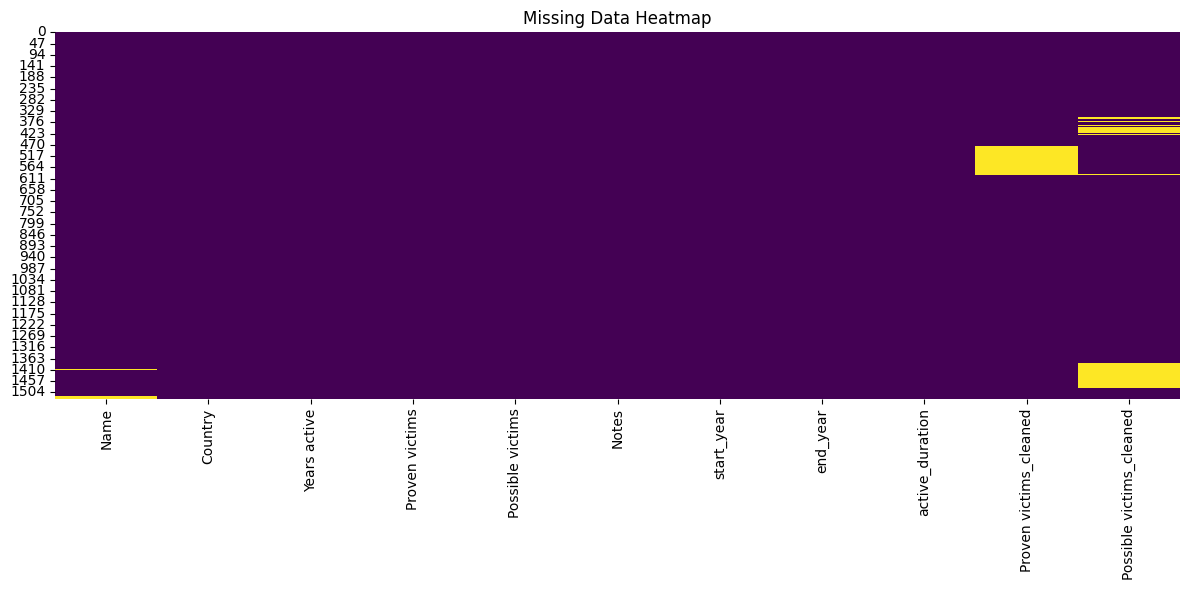

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Number of rows before dropping nulls: {df.shape[0]}")
df.dropna(inplace=True)
print(f"Number of rows after dropping nulls: {df.shape[0]}")

print("\nNull values after dropping all nulls:")
display(df.isnull().sum())

Number of rows before dropping nulls: 1531
Number of rows after dropping nulls: 1258

Null values after dropping all nulls:


,0
Name,0
Country,0
Years active,0
Proven victims,0
Possible victims,0
Notes,0
start_year,0
end_year,0
active_duration,0
Proven victims_cleaned,0


# **Sanchita Sarkar**

### Data Visualization

#### 1. Distribution of Active Duration

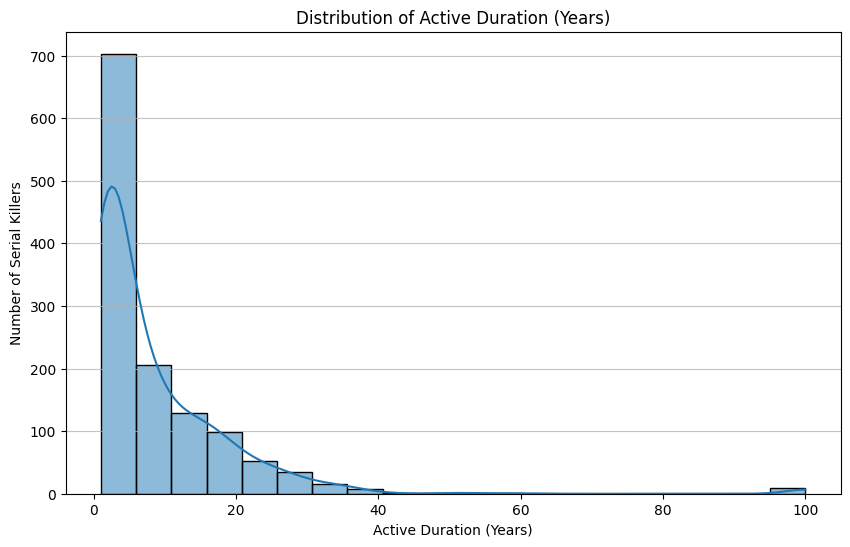

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['active_duration'].dropna(), bins=20, kde=True)
plt.title('Distribution of Active Duration (Years)')
plt.xlabel('Active Duration (Years)')
plt.ylabel('Number of Serial Killers')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 2. Distribution of Proven and Possible Victims

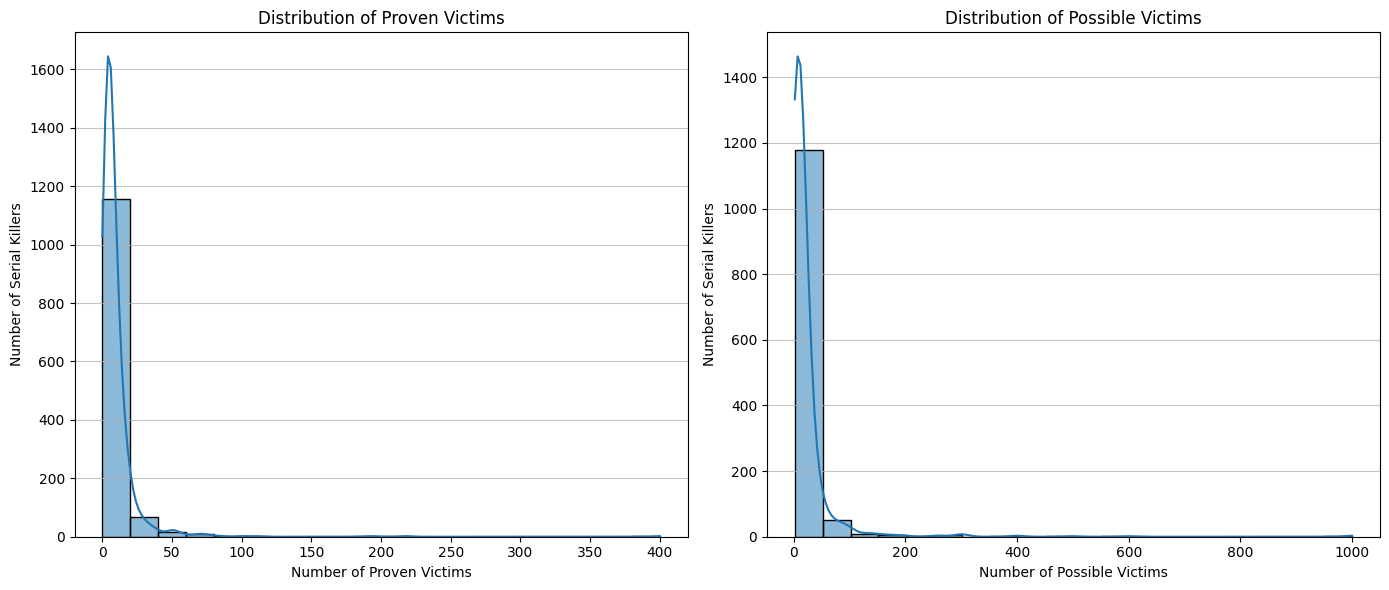

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Proven victims_cleaned'].dropna(), bins=20, kde=True)
plt.title('Distribution of Proven Victims')
plt.xlabel('Number of Proven Victims')
plt.ylabel('Number of Serial Killers')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
sns.histplot(df['Possible victims_cleaned'].dropna(), bins=20, kde=True)
plt.title('Distribution of Possible Victims')
plt.xlabel('Number of Possible Victims')
plt.ylabel('Number of Serial Killers')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### Duplication Removal

In [ ]:
initial_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()
print(f"Initial number of rows: {initial_rows}")
print(f"Number of duplicate rows found: {duplicate_rows}")

df.drop_duplicates(inplace=True)
final_rows = df.shape[0]
print(f"Number of rows after removing duplicates: {final_rows}")

if duplicate_rows > 0:
    print(f"Successfully removed {duplicate_rows} duplicate rows.")
else:
    print("No duplicate rows were found.")

Initial number of rows: 1258
Number of duplicate rows found: 0
Number of rows after removing duplicates: 1258
No duplicate rows were found.


### Feature Scaling / Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols_to_scale = ['active_duration', 'Proven victims_cleaned', 'Possible victims_cleaned']

scaler = MinMaxScaler()

df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Scaled numerical columns:")
display(df[numerical_cols_to_scale].head())
print("\nDescriptive statistics after scaling:")
display(df[numerical_cols_to_scale].describe())

Scaled numerical columns:


,active_duration,Proven victims_cleaned,Possible victims_cleaned
0,0.070707,0.4825,0.191383
1,0.111111,0.2750,0.298597
2,0.010101,0.2500,0.098196
3,0.181818,0.1950,0.081162
4,0.121212,0.1800,0.178357



Descriptive statistics after scaling:


,active_duration,Proven victims_cleaned,Possible victims_cleaned
count,1258.000000,1258.000000,1258.000000
mean,0.075685,0.023241,0.018432
std,0.114240,0.042851,0.056088
min,0.000000,0.000000,0.000000
25%,0.010101,0.007500,0.002004
50%,0.030303,0.012500,0.006012
75%,0.111111,0.025000,0.016032
max,1.000000,1.000000,1.000000


### Encoding Categorical Features

In [ ]:
if 'Country_cleaned' not in df.columns:
    def clean_country(country_str):
        if pd.isna(country_str):
            return np.nan
        country_str = str(country_str).strip()
        country_str = re.sub(r'\s*\([^)]*\)', '', country_str)
        country_str = re.sub(r'\s*\[[^\]]*\]', '', country_str)
        countries = re.split(r'[,; ]', country_str)
        return countries[0].strip() if countries else country_str.strip()

    df['Country_cleaned'] = df['Country'].apply(clean_country)

df['Country_cleaned'] = df['Country_cleaned'].fillna('Unknown_Country')

country_cols = [col for col in df.columns if col.startswith('Country_') and col != 'Country_cleaned']
df.drop(columns=country_cols, inplace=True, errors='ignore')

df = pd.get_dummies(df, columns=['Country_cleaned'], prefix='Country', dtype=int)

print("DataFrame after one-hot encoding 'Country_cleaned':")
display(df.head())

DataFrame after one-hot encoding 'Country_cleaned':


,Name,Country,Years active,Proven victims,Possible victims,Notes,start_year,end_year,active_duration,Proven victims_cleaned,...,Country_Switzerland,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Ukraine,Country_United,Country_Venezuela,Country_West,Country_Yemen,Country_Zambia
0,Luis Garavito,Colombia Ecuador[3] Venezuela[3],1992–1999[3],193,193–300+,"Child-murderer, torture-killer, and rapist kno...",1992,1999,0.070707,0.4825,...,0,0,0,0,0,0,0,0,0,0
1,Pedro López,Colombia Peru Ecuador,1969–1980,110,300+,"Child-murderer and rapist, known as ""The Monst...",1969,1980,0.111111,0.2750,...,0,0,0,0,0,0,0,0,0,0
2,Javed Iqbal,Pakistan,1998–1999,100,100,"Child-murderer and rapist, known as ""Kukri"", I...",1998,1999,0.010101,0.2500,...,0,0,0,0,0,0,0,0,0,0
3,Mikhail Popkov,Russia,1992–2010,78,83+,"Serial rapist-killer nicknamed ""The Werewolf"",...",1992,2010,0.181818,0.1950,...,0,0,0,0,0,0,0,0,0,0
4,Daniel Camargo Barbosa,Colombia Ecuador Brazil (alleged)[13],1974–1986,72,180[13],"Child and woman murderer, believed to have pos...",1974,1986,0.121212,0.1800,...,0,0,0,0,0,0,0,0,0,0


### Decade Analysis

In [ ]:
df['decade'] = (df['start_year'] // 10) * 10
display(df['decade'].value_counts().sort_index().head())

,count
decade,
1790,2
1800,1
1810,2
1840,2
1850,3


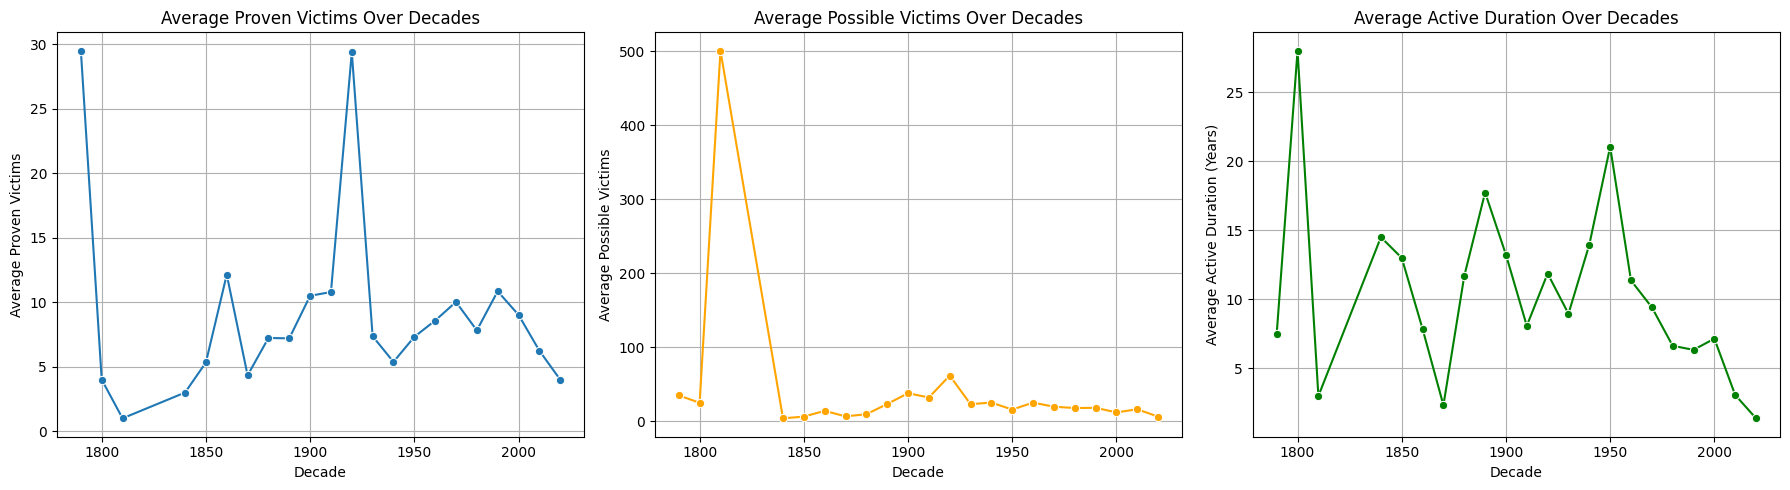

Analyzed and visualized trends in unscaled proven victims, possible victims, and active duration across different decades.


In [ ]:
df['Proven victims_cleaned_original'] = df['Proven victims'].apply(clean_victim_counts)
df['Possible victims_cleaned_original'] = df['Possible victims'].apply(clean_victim_counts)
df['active_duration_original'] = df['end_year'] - df['start_year'] + 1

decade_trends = df.groupby('decade')[['Proven victims_cleaned_original', 'Possible victims_cleaned_original', 'active_duration_original']].mean().reset_index()

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.lineplot(x='decade', y='Proven victims_cleaned_original', data=decade_trends, marker='o')
plt.title('Average Proven Victims Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Proven Victims')
plt.grid(True)

plt.subplot(1, 3, 2)
sns.lineplot(x='decade', y='Possible victims_cleaned_original', data=decade_trends, marker='o', color='orange')
plt.title('Average Possible Victims Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Possible Victims')
plt.grid(True)

plt.subplot(1, 3, 3)
sns.lineplot(x='decade', y='active_duration_original', data=decade_trends, marker='o', color='green')
plt.title('Average Active Duration Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Active Duration (Years)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Analyzed and visualized trends in unscaled proven victims, possible victims, and active duration across different decades.")

Correlation Matrix:


,active_duration,Proven victims_cleaned,Possible victims_cleaned,start_year,end_year,decade
active_duration,1.000000,0.070062,0.097527,-0.195805,0.164611,-0.183399
Proven victims_cleaned,0.070062,1.000000,0.546853,-0.040981,-0.015889,-0.038287
Possible victims_cleaned,0.097527,0.546853,1.000000,-0.140764,-0.106323,-0.137474
start_year,-0.195805,-0.040981,-0.140764,1.000000,0.935034,0.995598
end_year,0.164611,-0.015889,-0.106323,0.935034,1.000000,0.935092
decade,-0.183399,-0.038287,-0.137474,0.995598,0.935092,1.000000


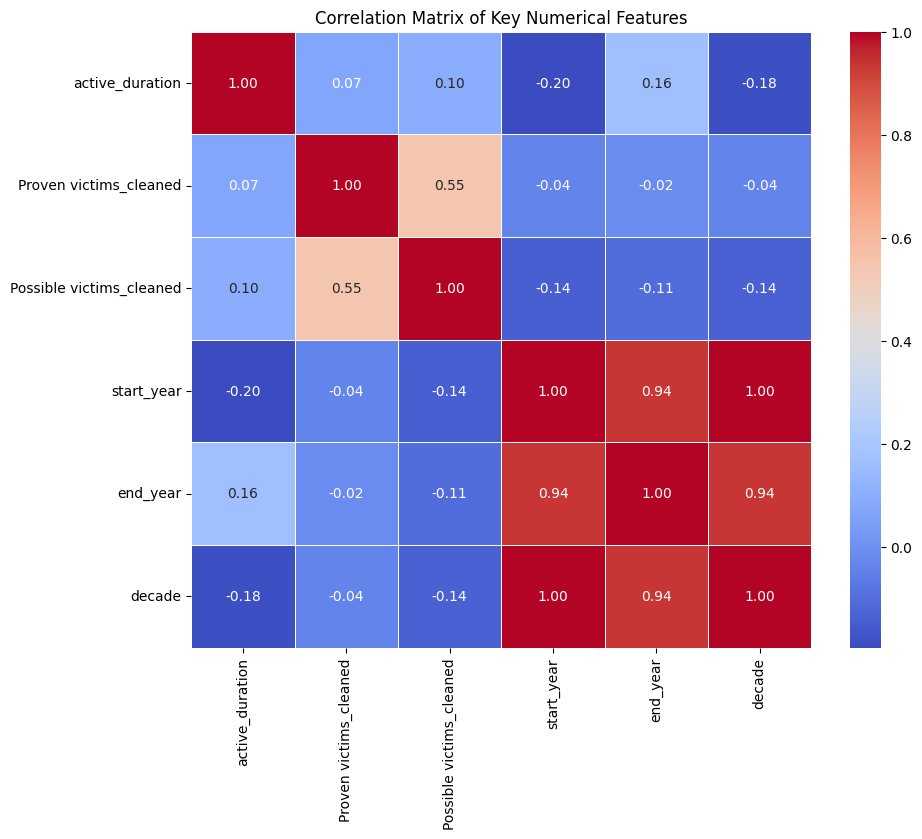

In [ ]:
numerical_features = ['active_duration', 'Proven victims_cleaned', 'Possible victims_cleaned', 'start_year', 'end_year', 'decade']

correlation_matrix = df[numerical_features].corr()

print("Correlation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Key Numerical Features')
plt.show()

In [ ]:
country_one_hot_cols = [col for col in df.columns if col.startswith('Country_')]

features_for_clustering_list = [
    'active_duration',
    'Proven victims_cleaned',
    'Possible victims_cleaned',
    'decade'
] + country_one_hot_cols

features_for_clustering = df[features_for_clustering_list].copy()

print(f"Shape of features_for_clustering DataFrame: {features_for_clustering.shape}")
print("First 5 rows of features_for_clustering:")
display(features_for_clustering.head())

Shape of features_for_clustering DataFrame: (1258, 75)
First 5 rows of features_for_clustering:


,active_duration,Proven victims_cleaned,Possible victims_cleaned,decade,Country_Allied-occupied,Country_Argentina,Country_Australia,Country_Austria,Country_Austria-Hungary,Country_Bangladesh,...,Country_Switzerland,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Ukraine,Country_United,Country_Venezuela,Country_West,Country_Yemen,Country_Zambia
0,0.070707,0.4825,0.191383,1990,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.111111,0.2750,0.298597,1960,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.010101,0.2500,0.098196,1990,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.181818,0.1950,0.081162,1990,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.121212,0.1800,0.178357,1970,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


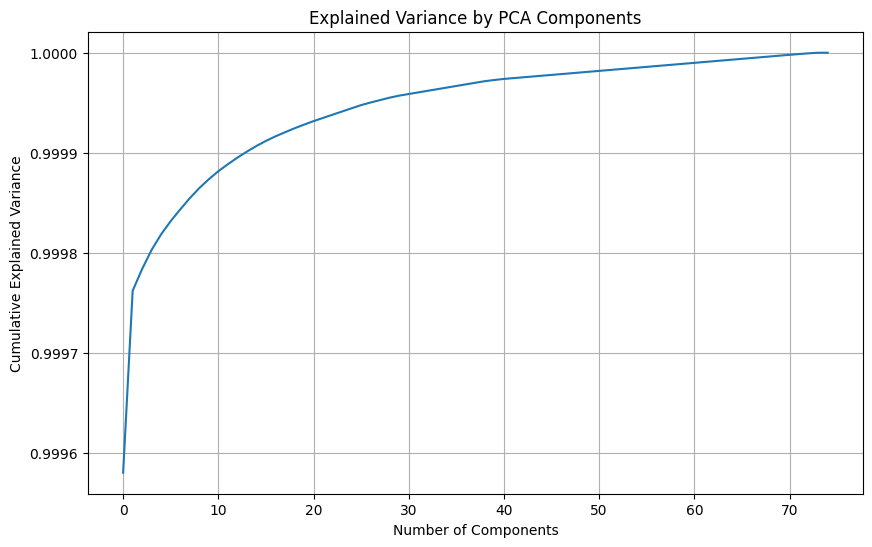

Number of components to retain 95% variance: 1
Shape of PCA transformed data: (1258, 1)


,PC_1
0,19.015731
1,-10.984238
2,19.015763
3,19.016118
4,-0.984235


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA()
pca.fit(features_for_clustering)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()


n_components = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components to retain 95% variance: {n_components}")

pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(features_for_clustering)

pca_df = pd.DataFrame(data=principal_components, columns=[f'PC_{i}' for i in range(1, n_components + 1)])

print("Shape of PCA transformed data:", pca_df.shape)
display(pca_df.head())

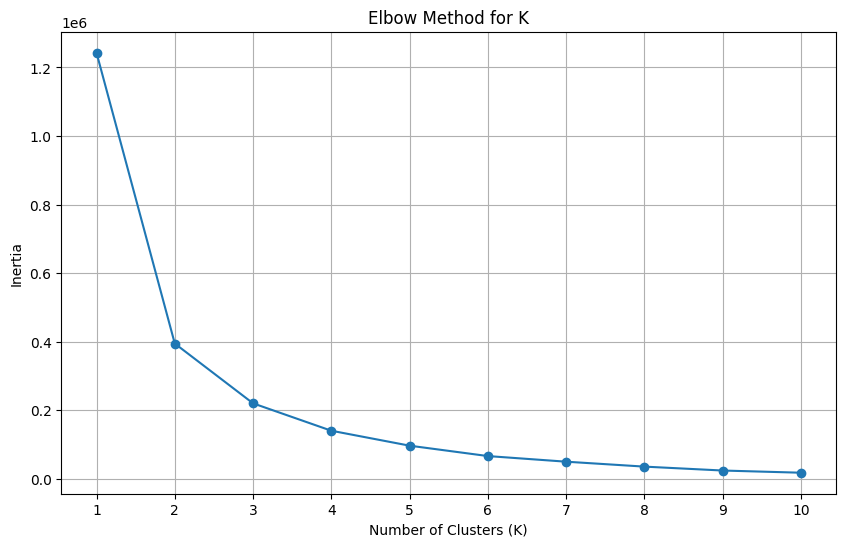

In [ ]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

#**Sumaita Mahdiat**

###KMeans Calculation

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(pca_df)
pca_df['Cluster'] = kmeans.labels_

print(f"K-Means clustering performed with {k} clusters.")
print("Count of observations per cluster:")
display(df['Cluster'].value_counts())

K-Means clustering performed with 3 clusters.
Count of observations per cluster:


,count
Cluster,
0,705
2,410
1,143


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

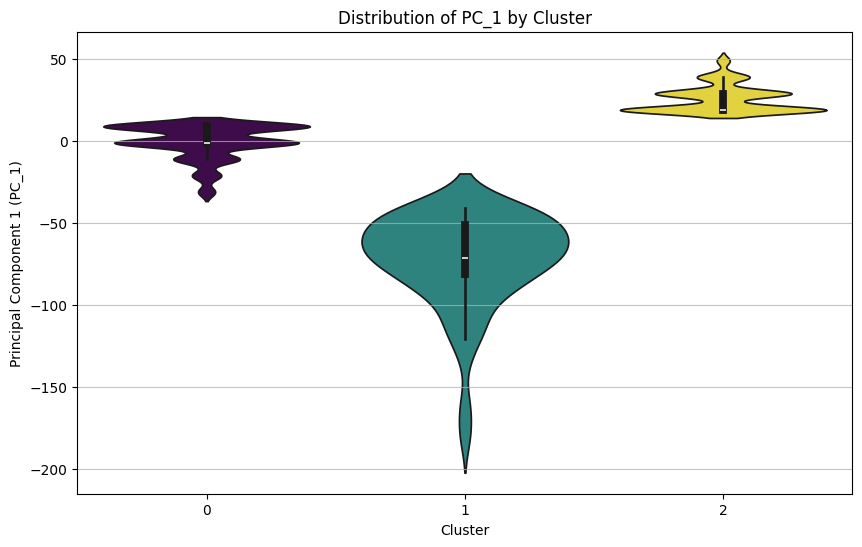

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Cluster', y='PC_1', data=pca_df, hue='Cluster', palette='viridis', legend=False)
plt.title('Distribution of PC_1 by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Principal Component 1 (PC_1)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
cluster_numerical = df.groupby('Cluster')[['active_duration', 'Proven victims_cleaned', 'Possible victims_cleaned', 'decade']].mean()

country_one_hot_cols = [col for col in df.columns if col.startswith('Country_')]
cluster_countries = df.groupby('Cluster')[country_one_hot_cols].sum()

print("Mean of numerical features per cluster:")
display(cluster_numerical)

print("\nTop 5 countries per cluster (by count):")
for cluster_id in cluster_countries.index:
    top_countries = cluster_countries.loc[cluster_id].nlargest(5)
    print(f"Cluster {cluster_id}:\n{top_countries}")
    print("---------------------------------")

Mean of numerical features per cluster:


,active_duration,Proven victims_cleaned,Possible victims_cleaned,decade
Cluster,,,,
0,0.084533,0.021535,0.017726,1970.595745
1,0.103270,0.030717,0.035897,1898.671329
2,0.050850,0.023567,0.013554,1996.878049



Top 5 countries per cluster (by count):
Cluster 0:
Country_United    607
Country_Soviet     17
Country_France      7
Country_Canada      6
Country_South       6
Name: 0, dtype: int64
---------------------------------
Cluster 1:
Country_United     113
Country_France       5
Country_Germany      4
Country_Kingdom      2
Country_Soviet       2
Name: 1, dtype: int64
---------------------------------
Cluster 2:
Country_United    251
Country_Russia     27
Country_South      20
Country_China      13
Country_Mexico     11
Name: 2, dtype: int64
---------------------------------


In [ ]:
from sklearn.decomposition import PCA
pca_2d = PCA(2)
principal_components_2d = pca_2d.fit_transform(features_for_clustering)
pca_df_2d = pd.DataFrame(data=principal_components_2d, columns=['PC_1', 'PC_2'])

pca_df_2d['Cluster'] = df['Cluster'].values
variance_ratio = pca_2d.explained_variance_ratio_
print(f"Explained variance ratio of PC1: {variance_ratio[0]:.2f}")
print(f"Explained variance ratio of PC2: {variance_ratio[1]:.2f}")
cluster_centroids = pca_df_2d.groupby('Cluster')[['PC_1', 'PC_2']].mean().reset_index()

Explained variance ratio of PC1: 1.00
Explained variance ratio of PC2: 0.00


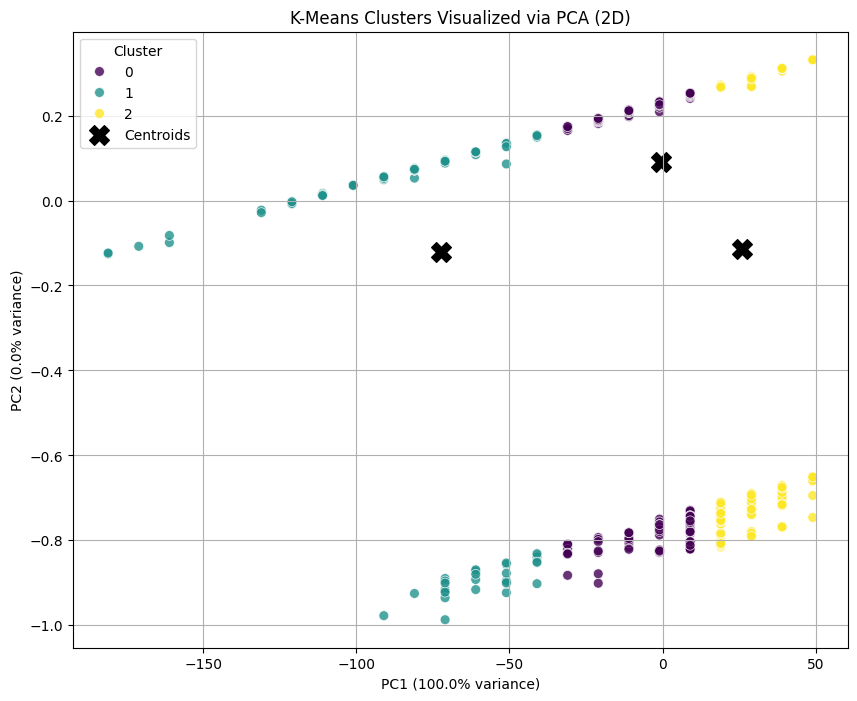

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC_1', y='PC_2', hue='Cluster', data=pca_df_2d,
    palette='viridis', s=50, alpha=0.8, legend='full'
)

plt.scatter(
    cluster_centroids['PC_1'], cluster_centroids['PC_2'],
    marker='X', s=200, color='black', label='Centroids'
)

plt.xlabel(f'PC1 ({variance_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({variance_ratio[1]*100:.1f}% variance)')

plt.title('K-Means Clusters Visualized via PCA (2D)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Silhouette Score Evaluation

In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(pca_df.drop('Cluster', axis=1), pca_df['Cluster'])
print(f"The average Silhouette Score for the K-Means clusters is: {silhouette:.4f}")

The average Silhouette Score for the K-Means clusters is: 0.6054


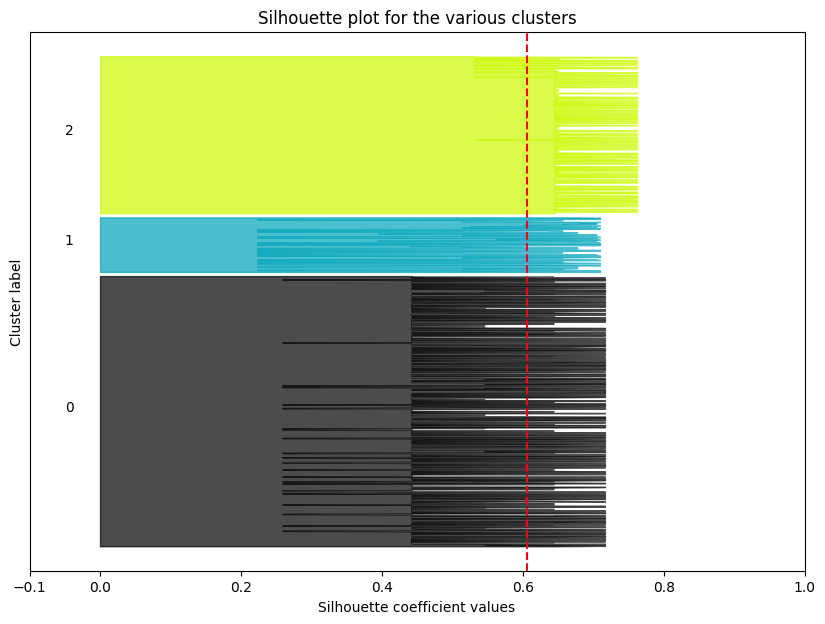

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

silhouette_values = silhouette_samples(pca_df.drop('Cluster', axis=1), pca_df['Cluster'])
silhouette_plot_df = pd.DataFrame({
    'silhouette_score': silhouette_values,
    'cluster': pca_df['Cluster'],
    'pc1': pca_df['PC_1']
})

silhouette_df = silhouette_plot_df.sort_values(by=['cluster', 'silhouette_score'], ascending=[True, True])
y_lower = 10
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title("Silhouette plot for the various clusters")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")

for i in range(k):
    i_data = silhouette_plot_df[silhouette_plot_df['cluster'] == i]['silhouette_score']
    cluster_i = len(i_data)
    y_upper = y_lower + cluster_i
    color = cm.nipy_spectral(float(i) / k)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        i_data,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    ax.text(-0.05, y_lower + 0.5 * cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette, color="red", linestyle="--")
ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()

### ANOVA Tests for Numerical Features Across Clusters

In [ ]:
from scipy.stats import f_oneway

features_anova = ['active_duration_original', 'Proven victims_cleaned_original', 'Possible victims_cleaned_original', 'decade']

print("ANOVA Test Results:")
for feature in features_anova:
    cluster_data = [df[feature][df['Cluster'] == c].dropna() for c in sorted(df['Cluster'].unique())]
    f_stat, p_value = f_oneway(*cluster_data)

    print(f"\nFeature: {feature}")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  Interpretation: There is a statistically significant difference between the means of this feature across clusters (p < 0.05).")
    else:
        print("  Interpretation: No statistically significant difference between the means of this feature across clusters (p >= 0.05).")

ANOVA Test Results:

Feature: active_duration_original
  F-statistic: 16.3625
  P-value: 0.0000
  Interpretation: There is a statistically significant difference between the means of this feature across clusters (p < 0.05).

Feature: Proven victims_cleaned_original
  F-statistic: 2.7542
  P-value: 0.0640
  Interpretation: No statistically significant difference between the means of this feature across clusters (p >= 0.05).

Feature: Possible victims_cleaned_original
  F-statistic: 8.6429
  P-value: 0.0002
  Interpretation: There is a statistically significant difference between the means of this feature across clusters (p < 0.05).

Feature: decade
  F-statistic: 2917.2210
  P-value: 0.0000
  Interpretation: There is a statistically significant difference between the means of this feature across clusters (p < 0.05).


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

arm_df = df[['active_duration_original', 'Proven victims_cleaned_original', 'Possible victims_cleaned_original', 'decade']].copy()
bins = [0, 5, 10, 20, 30, 50, arm_df['active_duration_original'].max() + 1]
labels = ['<5', '5-10', '10-20', '20-30', '30-50', '>50']
arm_df['active_duration_bin'] = pd.cut(arm_df['active_duration_original'], bins=bins, labels=labels, right=False)

bins = [0, 1, 5, 10, 20, 50, arm_df['Proven victims_cleaned_original'].max() + 1]
labels = ['0', '1-5', '5-10', '10-20', '20-50', '>50']
arm_df['proven_victims_bin'] = pd.cut(arm_df['Proven victims_cleaned_original'], bins=bins, labels=labels, right=False)

bins = [0, 1, 5, 10, 20, 50, arm_df['Possible victims_cleaned_original'].max() + 1]
labels = ['0', '1-5', '5-10', '10-20', '20-50', '>50']
arm_df['possible_victims_bin'] = pd.cut(arm_df['Possible victims_cleaned_original'], bins=bins, labels=labels, right=False)

bins = [1800, 1900, 1950, 1970, 1990, 2000, 2010, arm_df['decade'].max() + 10]
labels = ['<1900s', '1900s-1940s', '1950s-1960s', '1970s-1980s', '1990s', '2000s', '>2010s']
arm_df['decade_bin'] = pd.cut(arm_df['decade'], bins=bins, labels=labels, right=False)

In [ ]:
country_cols = [col for col in df.columns if col.startswith('Country_')]
arm_df_final = pd.concat([arm_df[['active_duration_bin', 'proven_victims_bin', 'possible_victims_bin', 'decade_bin']], df[country_cols]], axis=1)
arm_df_final = pd.get_dummies(arm_df_final, columns=['active_duration_bin', 'proven_victims_bin', 'possible_victims_bin', 'decade_bin'], dtype=bool)

print("DataFrame for Association Rule Mining (first 5 rows):")
display(arm_df_final.head())
print(f"Shape of ARM DataFrame: {arm_df_final.shape}")

DataFrame for Association Rule Mining (first 5 rows):


,Country_Allied-occupied,Country_Argentina,Country_Australia,Country_Austria,Country_Austria-Hungary,Country_Bangladesh,Country_Belarus,Country_Belgian,Country_Belgium,Country_Belize,...,possible_victims_bin_10-20,possible_victims_bin_20-50,possible_victims_bin_>50,decade_bin_<1900s,decade_bin_1900s-1940s,decade_bin_1950s-1960s,decade_bin_1970s-1980s,decade_bin_1990s,decade_bin_2000s,decade_bin_>2010s
0,0,0,0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,True,False,False
1,0,0,0,0,0,0,0,0,0,0,...,False,False,True,False,False,True,False,False,False,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,True,False,False
3,0,0,0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,True,False,False
4,0,0,0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,True,False,False,False


Shape of ARM DataFrame: (1258, 96)


### Applying Apriori Algorithm and Generating Association Rules

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

items = apriori(arm_df_final, min_support=0.01, use_colnames=True)
rules = association_rules(items, metric="lift", min_threshold=1)

print("Top 10 Association Rules (sorted by Lift):")
display(rules.sort_values('lift', ascending=False).head(10))
print("\nTop 10 Association Rules (sorted by Confidence):")
display(rules.sort_values('confidence', ascending=False).head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 10 Association Rules (sorted by Lift):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
133,(possible_victims_bin_>50),(proven_victims_bin_>50),0.070747,0.019078,0.019078,0.269663,14.134831,1.0,0.017728,1.343109,1.000000,0.269663,0.255459,0.634831
132,(proven_victims_bin_>50),(possible_victims_bin_>50),0.019078,0.070747,0.019078,1.000000,14.134831,1.0,0.017728,inf,0.947326,0.269663,1.000000,0.634831
554,"(proven_victims_bin_20-50, active_duration_bin...",(possible_victims_bin_20-50),0.022258,0.149444,0.020668,0.928571,6.213526,1.0,0.017341,11.907790,0.858161,0.136842,0.916021,0.533435
557,(possible_victims_bin_20-50),"(proven_victims_bin_20-50, active_duration_bin...",0.149444,0.022258,0.020668,0.138298,6.213526,1.0,0.017341,1.134664,0.986485,0.136842,0.118682,0.533435
650,"(active_duration_bin_5-10, possible_victims_bi...",(proven_victims_bin_20-50),0.038156,0.060413,0.014308,0.375000,6.207237,1.0,0.012003,1.503339,0.872176,0.169811,0.334814,0.305921
651,(proven_victims_bin_20-50),"(active_duration_bin_5-10, possible_victims_bi...",0.060413,0.038156,0.014308,0.236842,6.207237,1.0,0.012003,1.260348,0.892837,0.169811,0.206568,0.305921
1585,"(decade_bin_1970s-1980s, possible_victims_bin_...","(proven_victims_bin_20-50, Country_United)",0.066773,0.027027,0.011129,0.166667,6.166667,1.0,0.009324,1.167568,0.897785,0.134615,0.143519,0.289216
1584,"(proven_victims_bin_20-50, Country_United)","(decade_bin_1970s-1980s, possible_victims_bin_...",0.027027,0.066773,0.011129,0.411765,6.166667,1.0,0.009324,1.586486,0.861111,0.134615,0.369676,0.289216
1782,"(possible_victims_bin_10-20, active_duration_b...","(decade_bin_1990s, proven_victims_bin_10-20)",0.050079,0.037361,0.011129,0.222222,5.947991,1.0,0.009258,1.237679,0.875732,0.145833,0.192036,0.260047
1783,"(decade_bin_1990s, proven_victims_bin_10-20)","(possible_victims_bin_10-20, active_duration_b...",0.037361,0.050079,0.011129,0.297872,5.947991,1.0,0.009258,1.352917,0.864162,0.145833,0.260856,0.260047


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Top 10 Association Rules (sorted by Confidence):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
768,"(possible_victims_bin_1-5, decade_bin_>2010s)",(proven_victims_bin_1-5),0.021463,0.427663,0.021463,1.0,2.338290,1.0,0.012284,inf,0.584890,0.050186,1.0,0.525093
738,"(decade_bin_<1900s, possible_victims_bin_1-5)",(proven_victims_bin_1-5),0.011924,0.427663,0.011924,1.0,2.338290,1.0,0.006824,inf,0.579244,0.027881,1.0,0.513941
744,"(possible_victims_bin_1-5, decade_bin_1900s-19...",(proven_victims_bin_1-5),0.014308,0.427663,0.014308,1.0,2.338290,1.0,0.008189,inf,0.580645,0.033457,1.0,0.516729
748,"(decade_bin_1950s-1960s, possible_victims_bin_...",(proven_victims_bin_1-5),0.036566,0.427663,0.036566,1.0,2.338290,1.0,0.020928,inf,0.594059,0.085502,1.0,0.542751
724,"(active_duration_bin_20-30, possible_victims_b...",(proven_victims_bin_1-5),0.018283,0.427663,0.018283,1.0,2.338290,1.0,0.010464,inf,0.582996,0.042751,1.0,0.521375
2185,"(decade_bin_1970s-1980s, active_duration_bin_1...",(proven_victims_bin_1-5),0.024642,0.427663,0.024642,1.0,2.338290,1.0,0.014104,inf,0.586797,0.057621,1.0,0.528810
2212,"(decade_bin_1970s-1980s, active_duration_bin_1...",(Country_United),0.012719,0.771860,0.012719,1.0,1.295572,1.0,0.002902,inf,0.231079,0.016478,1.0,0.508239
2182,"(decade_bin_1970s-1980s, active_duration_bin_1...",(Country_United),0.024642,0.771860,0.024642,1.0,1.295572,1.0,0.005622,inf,0.233904,0.031926,1.0,0.515963
1332,"(decade_bin_1970s-1980s, active_duration_bin_1...",(Country_United),0.018283,0.771860,0.018283,1.0,1.295572,1.0,0.004171,inf,0.232389,0.023687,1.0,0.511843
1318,"(decade_bin_1970s-1980s, active_duration_bin_1...",(Country_United),0.024642,0.771860,0.024642,1.0,1.295572,1.0,0.005622,inf,0.233904,0.031926,1.0,0.515963


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = features_for_clustering
y = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Value counts of y_train:\n{y_train.value_counts()}")
print(f"Value counts of y_test:\n{y_test.value_counts()}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Shape of X_train: (880, 75)
Shape of X_test: (378, 75)
Value counts of y_train:
Cluster
0    493
2    287
1    100
Name: count, dtype: int64
Value counts of y_test:
Cluster
0    212
2    123
1     43
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=dt_classifier.classes_, columns=dt_classifier.classes_))

feature_importances = pd.Series(dt_classifier.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 Most Important Features:")
display(feature_importances.head(10))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       212
           1       1.00      1.00      1.00        43
           2       1.00      1.00      1.00       123

    accuracy                           1.00       378
   macro avg       1.00      1.00      1.00       378
weighted avg       1.00      1.00      1.00       378


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0,1,2
0,212,0,0
1,0,43,0
2,0,0,123



Top 10 Most Important Features:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
decade,1.0
Proven victims_cleaned,0.0
active_duration,0.0
Possible victims_cleaned,0.0
Country_Allied-occupied,0.0
Country_Argentina,0.0
Country_Australia,0.0
Country_Austria,0.0
Country_Austria-Hungary,0.0
Country_Bangladesh,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **Sharan Perris**

In [ ]:
if 'start_year_raw' not in globals() or start_year_raw.isnull().all():

    def get_years(text):
        if pd.isna(text):
            return np.nan, np.nan

        text = str(text).split('[')[0].strip()
        parts = text.replace('–', '-').replace(' ', '').split('-')

        nums = []
        for p in parts:
            if p.isdigit():
                nums.append(int(p))

        if len(nums) == 1:
            return nums[0], nums[0]
        elif len(nums) == 2:
            return nums[0], nums[1]
        else:
            return np.nan, np.nan

    start_year_raw = df['Years active'].apply(lambda x: get_years(x)[0])
    start_year_raw = start_year_raw.fillna(1981.0)

years = start_year_raw[start_year_raw >= 1900]

counts = years.value_counts().sort_index()

start = int(counts.index.min())
end = int(counts.index.max())

all_years = pd.Series(0, index=range(start, end + 1))

freq = all_years + counts
freq = freq.fillna(0).astype(int)


print("First 5:")
display(freq.head())

print("\nLast 5:")
display(freq.tail())

First 5:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
1900.0,8
1901.0,0
1902.0,1
1903.0,0
1904.0,3



Last 5:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
2018.0,5
2019.0,3
2020.0,6
2021.0,6
2022.0,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Visualize the Time Series

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

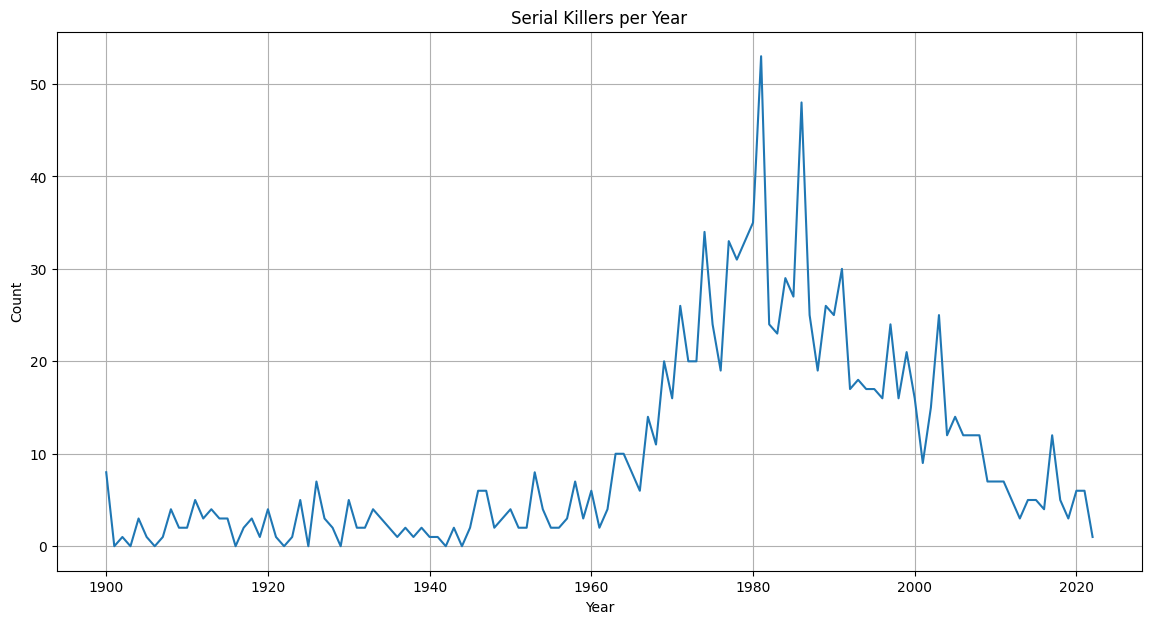

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.figure(figsize=(14, 7))

sns.lineplot(x=freq.index, y=freq.values)

plt.title("Serial Killers per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.grid(True)
plt.show()

# ARIMA Modeling for Trend Analysis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ADF Test Result:
ADF Statistic: -1.5987
p-value: 0.4843
Critical Values:
1% : -3.4891
5% : -2.8872
10% : -2.5805
Series is not stationary (need differencing)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


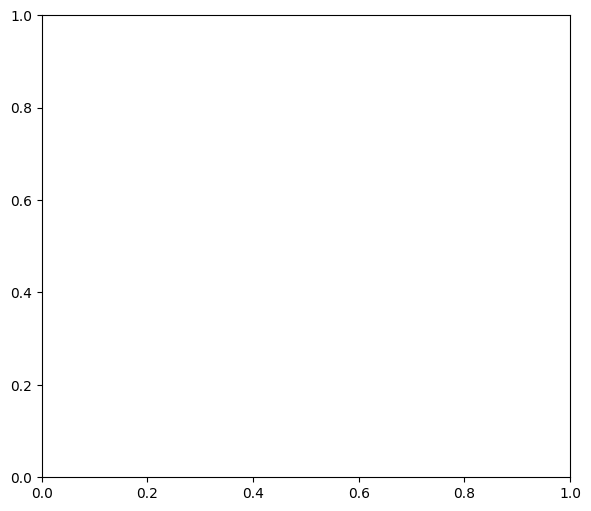

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

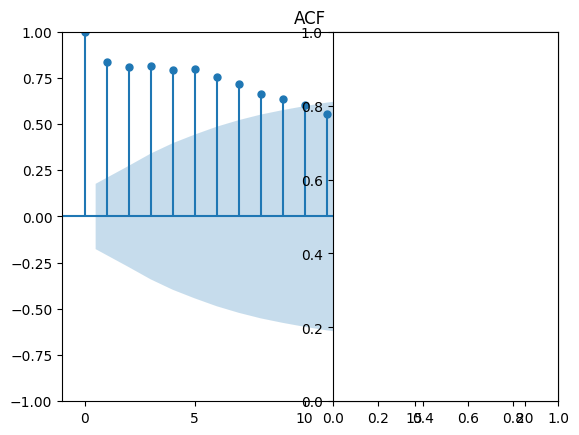

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

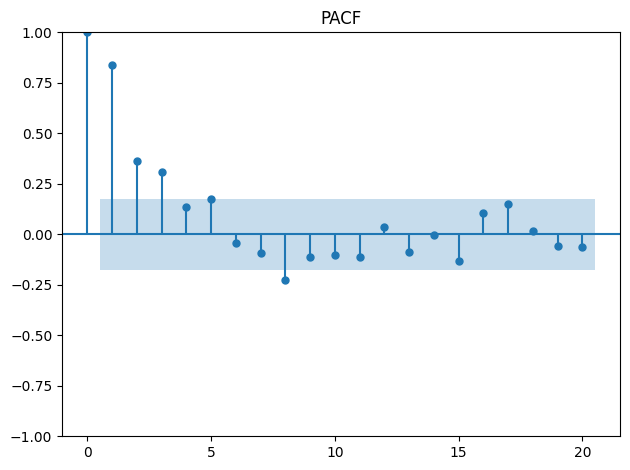

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


ts = pd.Series(freq.values, index=pd.to_datetime(freq.index, format='%Y'))

print("ADF Test Result:")

adf_result = adfuller(ts)

print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))

print("Critical Values:")
for k, v in adf_result[4].items():
    print(k, ":", round(v, 4))

if adf_result[1] <= 0.05:
    print("Series is stationary")
else:
    print("Series is not stationary (need differencing)")


plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plot_acf(ts, lags=20)
plt.title("ACF")

plt.subplot(1, 2, 2)
plot_pacf(ts, lags=20)
plt.title("PACF")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Using order: (1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  123
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -373.255
Date:                Thu, 30 Apr 2026   AIC                            752.510
Time:                        17:51:25   BIC                            760.922
Sample:                    01-01-1900   HQIC                           755.927
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0547      0.084     -0.651      0.515      -0.220       0.110
ma.L1         -0.5822      0.072     -8.098      0.000      -0.723      -0.441
sigma2        26.4994      1.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

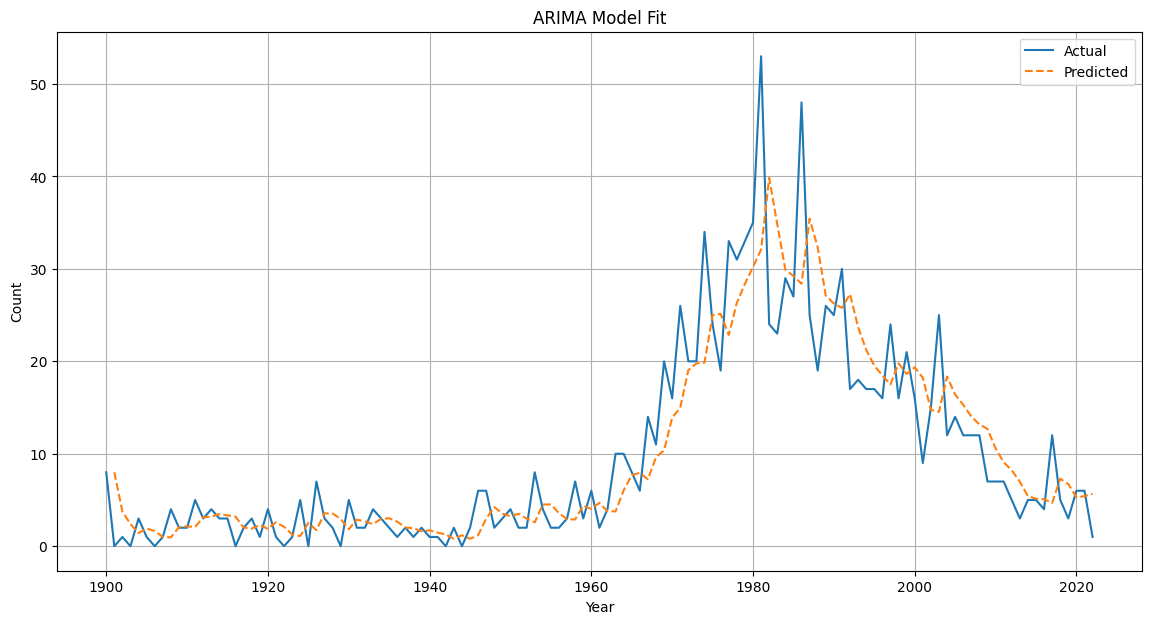

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
adf_check = adfuller(ts)
d = 1 if adf_check[1] > 0.05 else 0

order = (1, d, 1)

print("Using order:", order)

model = ARIMA(ts, order=order)
model_fit = model.fit()

print(model_fit.summary())


plt.figure(figsize=(14, 7))

plt.plot(ts, label="Actual")
plt.plot(model_fit.predict(start=ts.index[d], end=ts.index[-1]),
         label="Predicted", linestyle='--')

plt.title("ARIMA Model Fit")
plt.xlabel("Year")
plt.ylabel("Count")

plt.legend()
plt.grid(True)
plt.show()

# Analyze Trends and Forecast

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

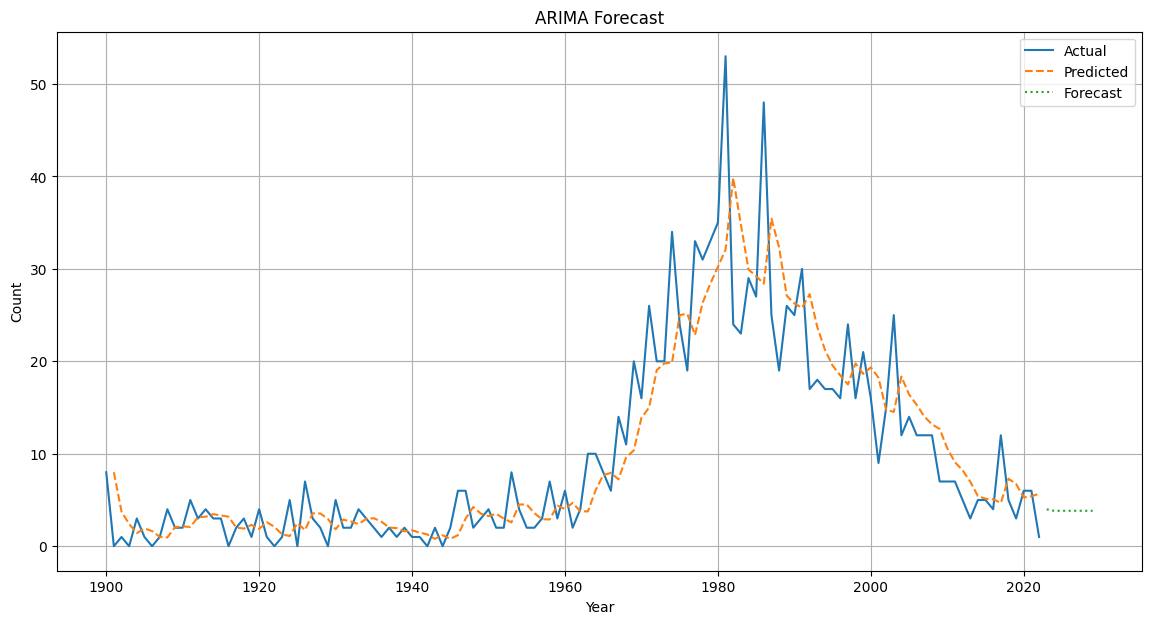

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Trend Analysis:
Avg before 1970: 3.49
Avg after 1970: 18.28
Avg before 2000: 10.1
Avg after 2000: 8.83


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
steps = 7

forecast = model_fit.forecast(steps=steps)

last_year = ts.index.year.max()
future_years = pd.to_datetime(range(last_year + 1, last_year + 1 + steps), format='%Y')
forecast.index = future_years


plt.figure(figsize=(14, 7))

plt.plot(ts, label="Actual")
plt.plot(model_fit.predict(start=ts.index[d], end=ts.index[-1]),
         label="Predicted", linestyle='--')
plt.plot(forecast, label="Forecast", linestyle=':')

plt.title("ARIMA Forecast")
plt.xlabel("Year")
plt.ylabel("Count")

plt.legend()
plt.grid(True)
plt.show()


print("Trend Analysis:")

before_1970 = ts[ts.index.year < 1970].mean()
after_1970 = ts[ts.index.year >= 1970].mean()

print("Avg before 1970:", round(before_1970, 2))
print("Avg after 1970:", round(after_1970, 2))


before_2000 = ts[ts.index.year < 2000].mean()
after_2000 = ts[ts.index.year >= 2000].mean()

print("Avg before 2000:", round(before_2000, 2))
print("Avg after 2000:", round(after_2000, 2))

# Data Preparation for Supervised Learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


df['victim_category'] = pd.cut(
    df['Proven victims_cleaned_original'],
    bins=[0, 5, 15, 50, float('inf')],
    labels=['Low', 'Medium', 'High', 'Extreme']
)

df_sup = df.dropna(subset=['victim_category']).copy()

feature_cols = ['active_duration', 'Possible victims_cleaned', 'decade'] + \
               [c for c in df.columns if c.startswith('Country_')]
feature_cols = [c for c in feature_cols if c in df.columns]

X = df_sup[feature_cols]
y = df_sup['victim_category']

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)


print("Total rows in df         :", df.shape[0])
print("Rows after dropna        :", df_sup.shape[0])
print("Number of features       :", X.shape[1])
print("Number of classes        :", len(encoder.classes_))
print("Classes                  :", list(encoder.classes_))
print("\nClass distribution:")
print(df_sup['victim_category'].value_counts().sort_index())

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

display(X_train.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total rows in df         : 1258
Rows after dropna        : 1241
Number of features       : 74
Number of classes        : 4
Classes                  : ['Extreme', 'High', 'Low', 'Medium']

Class distribution:
victim_category
Low        650
Medium     429
High       141
Extreme     21
Name: count, dtype: int64

Train size: 992
Test size : 249


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,active_duration,Possible victims_cleaned,decade,Country_Allied-occupied,Country_Argentina,Country_Australia,Country_Austria,Country_Austria-Hungary,Country_Bangladesh,Country_Belarus,...,Country_Switzerland,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Ukraine,Country_United,Country_Venezuela,Country_West,Country_Yemen,Country_Zambia
132,0.040404,0.038076,1930,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
5,0.363636,0.098196,1960,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
298,0.050505,0.080160,1990,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1369,0.010101,0.005010,1970,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
287,0.000000,0.020040,2000,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score


dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

labels = np.unique(y_test)
class_names = encoder.inverse_transform(labels)

print("\nReport:")
print(classification_report(y_test, y_pred, labels=labels, target_names=class_names))

imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop Features:")
display(imp.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Decision Tree Results
Accuracy: 0.7671

Report:
              precision    recall  f1-score   support

     Extreme       0.67      1.00      0.80         4
        High       0.57      0.57      0.57        28
         Low       0.85      0.83      0.84       131
      Medium       0.71      0.72      0.72        86

    accuracy                           0.77       249
   macro avg       0.70      0.78      0.73       249
weighted avg       0.77      0.77      0.77       249


Top Features:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
Possible victims_cleaned,0.591311
active_duration,0.195577
decade,0.117469
Country_United,0.025070
Country_South,0.006520
Country_Japan,0.006019
Country_Netherlands,0.005706
Country_Mexico,0.004937
Country_Austria,0.004363
Country_Italy,0.003934


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Importance Of Feature

In [ ]:
imp = pd.Series(dt.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False)

print("\nTop Features:")
display(imp.head(10))


Top Features:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
Possible victims_cleaned,0.591311
active_duration,0.195577
decade,0.117469
Country_United,0.025070
Country_South,0.006520
Country_Japan,0.006019
Country_Netherlands,0.005706
Country_Mexico,0.004937
Country_Austria,0.004363
Country_Italy,0.003934


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Visualize

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

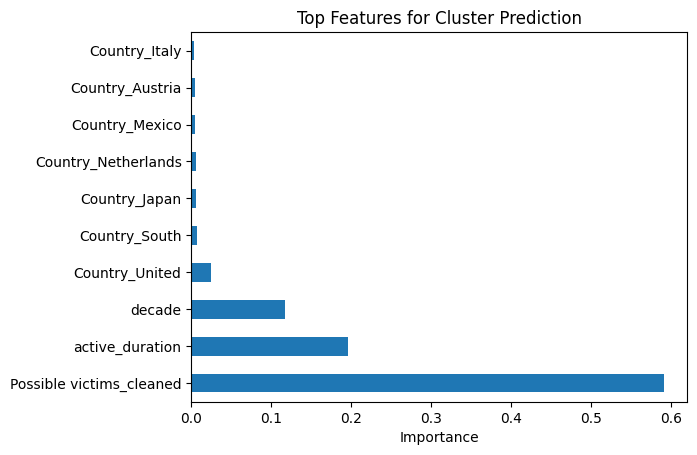

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
imp.head(10).plot(kind='barh')
plt.title("Top Features for Cluster Prediction")
plt.xlabel("Importance")
plt.show()